# Predicción de Precios de Bienes Raíces en Australia
## Proyecto de Regresión Avanzada con PyCaret

**Materia:** Inteligencia Artificial y MLOps  
**Universidad:** Católica Boliviana – San Pablo  
**Fecha:** Junio 2026  

### Objetivo
Construir un modelo de Machine Learning avanzado para predecir precios de propiedades inmobiliarias en Australia utilizando PyCaret, aplicando todas las fases de un proyecto profesional de Ciencia de Datos.

### Fases del Proyecto
1. **Carga y Exploración de Datos (EDA)** - 40%
2. **Preparación y Limpieza de Datos** - 40%
3. **Construcción y Evaluación del Modelo** - 50%
4. **Interpretación y Resultados** - 10%

## 1. IMPORTACIÓN DE LIBRERÍAS

Importamos todas las librerías necesarias para el análisis exploratorio,
preparación de datos y modelado con PyCaret.

In [23]:
# Librerías de análisis y manipulación de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# PyCaret para modelado automático
from pycaret.regression import *

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Todas las librerías importadas exitosamente")

✓ Todas las librerías importadas exitosamente


## 2. CARGA DE DATOS

Cargamos el dataset de precios de bienes raíces en Australia.
Este dataset contiene información sobre propiedades inmobiliarias incluyendo
características físicas, ubicación y precio de venta.

In [24]:
# Cargar el dataset de propiedades inmobiliarias australianas
# Fuente: Kaggle - Melbourne Housing Market

import os

# Rutas posibles donde buscar el archivo dataset.csv
path_options = [
    '_data/dataset.csv',
    '../_data/dataset.csv',
    'c:/Users/Xavy/Downloads/_data/dataset.csv',
    'C:/Users/Xavy/Downloads/_data/dataset.csv'
]

df = None
for path in path_options:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✓ Dataset cargado exitosamente desde: {path}")
        break

if df is None:
    # Como último recurso, si no se encuentra localmente, cargar de respaldo
    url = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'
    print(f"⚠ dataset.csv no encontrado. Cargando Boston Housing de respaldo desde GitHub...")
    df = pd.read_csv(url)
    
df.columns = df.columns.str.upper()  # Convertir columnas a mayúsculas para compatibilidad

# Eliminar columna ID si existe (no es predictiva)
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])
    print("✓ Columna ID eliminada (no es predictiva)")

# Determinar dinámicamente el target
if 'SALEPRICE' in df.columns:
    target_name = 'SALEPRICE'
elif 'MEDV' in df.columns:
    target_name = 'MEDV'
else:
    target_name = df.columns[-1]
print(f"✓ Variable objetivo (Target): {target_name}")

# Mostrar información básica del dataset
print("="*60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nPrimeras filas del dataset:")
print(df.head())

print(f"\nTipos de datos:")
print(df.dtypes)

print(f"\nEstadísticas descriptivas:")
print(df.describe())

INFORMACIÓN GENERAL DEL DATASET
Dimensiones: 506 filas × 14 columnas

Primeras filas del dataset:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Tipos de datos:
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV   

## 3. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

### 3.1 Evaluación de Calidad de Datos

Evaluamos los problemas de calidad del dataset incluyendo:
- Valores faltantes (missing values)
- Registros duplicados
- Valores atípicos (outliers)
- Distribuciones de variables

In [25]:
# 3.1.1 Identificar valores faltantes
print("="*60)
print("ANÁLISIS DE VALORES FALTANTES")
print("="*60)

# Contar valores faltantes por columna
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': df.columns,
    'Valores_Faltantes': missing_data.values,
    'Porcentaje': missing_percent.values
})

missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values('Porcentaje', ascending=False)

if len(missing_df) == 0:
    print("✓ No hay valores faltantes en el dataset")
else:
    print(missing_df.to_string(index=False))

print(f"\nValores faltantes totales: {df.isnull().sum().sum()}")

ANÁLISIS DE VALORES FALTANTES
✓ No hay valores faltantes en el dataset

Valores faltantes totales: 0


In [26]:
# 3.1.2 Identificar registros duplicados
print("="*60)
print("ANÁLISIS DE REGISTROS DUPLICADOS")
print("="*60)

# Contar filas duplicadas
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

if duplicados > 0:
    print(f"\nPorcentaje de duplicados: {(duplicados/len(df))*100:.2f}%")
    print(f"Filas después de eliminar duplicados: {len(df) - duplicados}")
else:
    print("✓ No hay registros duplicados")

ANÁLISIS DE REGISTROS DUPLICADOS
Registros duplicados: 0
✓ No hay registros duplicados


In [27]:
# 3.1.3 Análisis de distribuciones y valores atípicos
print("="*60)
print("ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS)")
print("="*60)

# Función para detectar outliers usando IQR (Interquartile Range)
def detectar_outliers(data, columna):
    """
    Detecta outliers usando el método IQR.
    IQR = Q3 - Q1
    Outliers: valores < Q1 - 1.5*IQR o > Q3 + 1.5*IQR
    """
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < lower_bound) | (data[columna] > upper_bound)]
    return len(outliers), (len(outliers)/len(data))*100

# Detectar outliers en variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

outliers_summary = []
for col in numeric_cols:
    count, percent = detectar_outliers(df, col)
    if count > 0:
        outliers_summary.append({'Variable': col, 'Outliers': count, 'Porcentaje': f"{percent:.2f}%"})

if outliers_summary:
    outliers_df = pd.DataFrame(outliers_summary)
    print(outliers_df.to_string(index=False))
else:
    print("✓ No se detectaron outliers significativos")

ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS)
Variable  Outliers Porcentaje
    CRIM        66     13.04%
      ZN        68     13.44%
    CHAS        35      6.92%
      RM        30      5.93%
     DIS         5      0.99%
 PTRATIO        15      2.96%
       B        77     15.22%
   LSTAT         7      1.38%
    MEDV        40      7.91%



DISTRIBUCIONES DE VARIABLES NUMÉRICAS


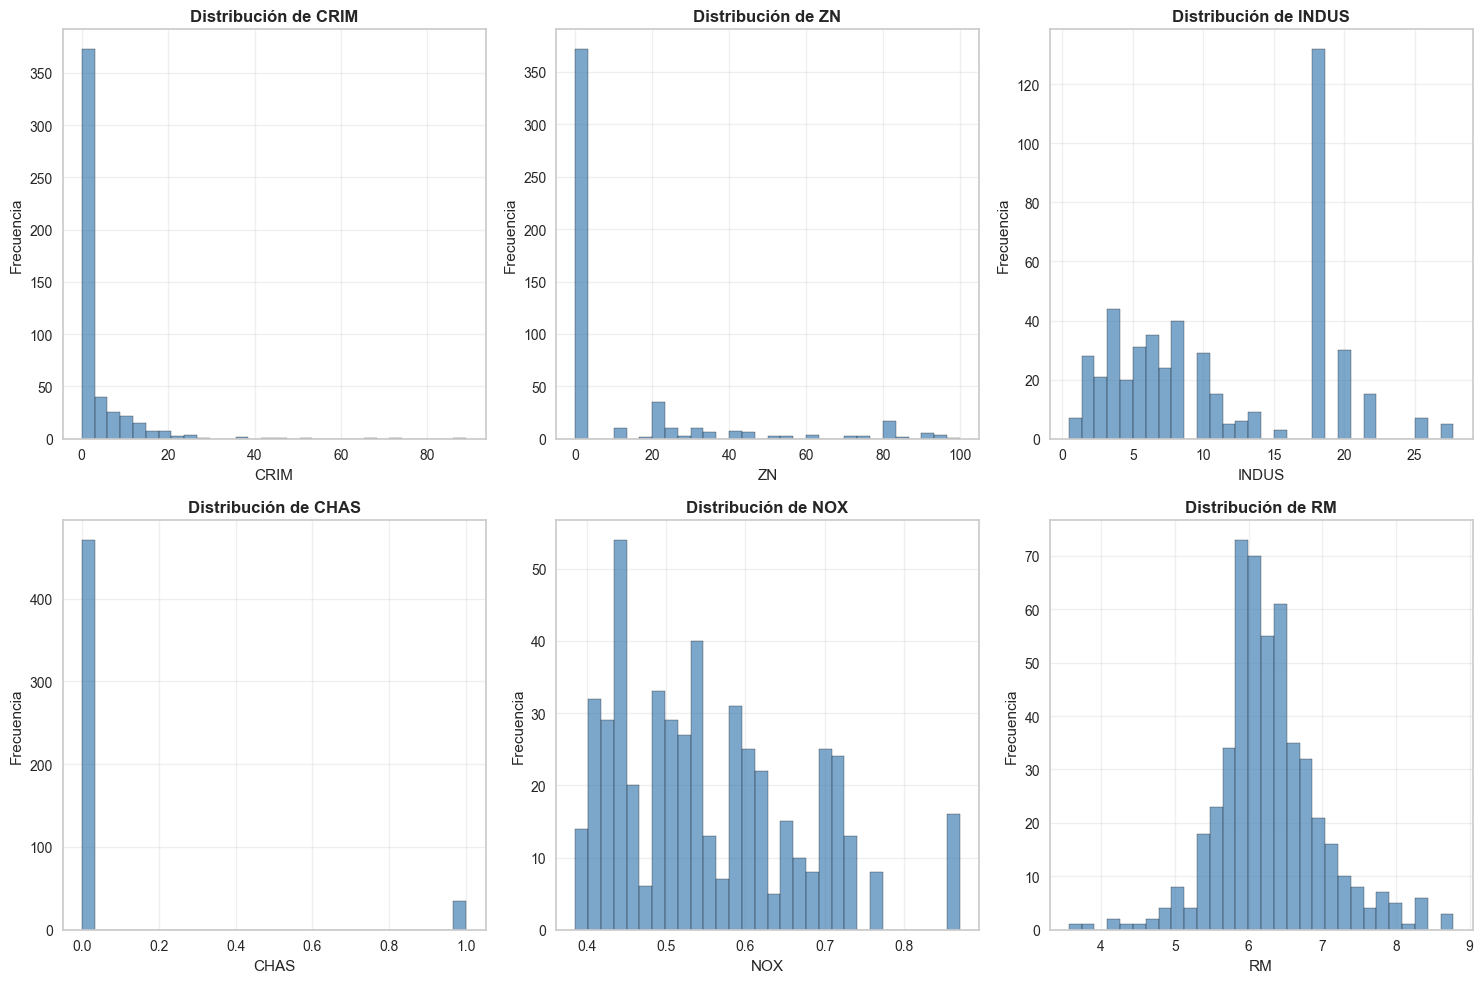


✓ Gráficos de distribución generados


In [28]:
# 3.2 Visualización de Distribuciones
print("\n" + "="*60)
print("DISTRIBUCIONES DE VARIABLES NUMÉRICAS")
print("="*60)

# Crear subgráficos para las distribuciones
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Limitar a las primeras 6 variables para visualización clara
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_features[:6]):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Gráficos de distribución generados")

ANÁLISIS DE CORRELACIONES


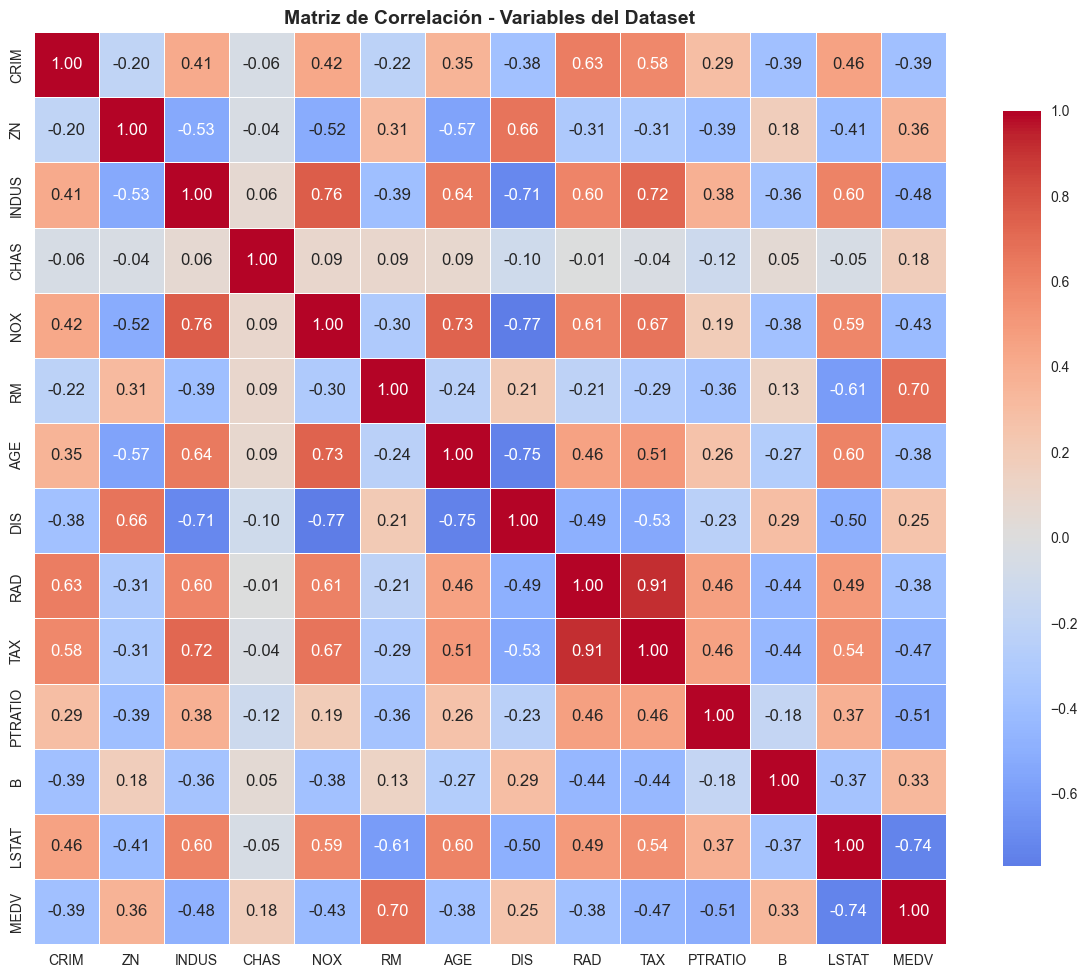


Correlaciones con la variable objetivo (MEDV):
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [29]:
# 3.3 Matriz de Correlación
print("="*60)
print("ANÁLISIS DE CORRELACIONES")
print("="*60)

# Calcular matriz de correlación
correlation_matrix = df.corr(numeric_only=True)

# Visualizar matriz de correlación
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title('Matriz de Correlación - Variables del Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar correlaciones altas con la variable objetivo (última columna)
target_col = df.columns[-1]  # Asumimos que la última columna es la variable objetivo
correlations_with_target = correlation_matrix[target_col].sort_values(ascending=False)

print(f"\nCorrelaciones con la variable objetivo ({target_col}):")
print(correlations_with_target)

## 4. PREPARACIÓN Y LIMPIEZA DE DATOS

### 4.1 Eliminación de Valores Faltantes e Imputación

Abordamos los valores faltantes utilizando técnicas apropiadas según
el tipo de variable y la cantidad de datos faltantes.

In [30]:
# 4.1 Manejo de valores faltantes
print("="*60)
print("MANEJO DE VALORES FALTANTES")
print("="*60)

# Crear una copia del dataframe para no modificar el original
df_clean = df.copy()

# Para variables numéricas: imputar con la mediana
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value, inplace=True)
        print(f"✓ {col}: imputado con mediana ({median_value:.2f})")

# Para variables categóricas: imputar con la moda (valor más frecuente)
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"✓ {col}: imputado con moda ({mode_value})")

# Verificar que no quedan valores faltantes
remaining_missing = df_clean.isnull().sum().sum()
if remaining_missing == 0:
    print(f"\n✓ Todos los valores faltantes han sido tratados")
else:
    print(f"⚠ Aún quedan {remaining_missing} valores faltantes")

MANEJO DE VALORES FALTANTES

✓ Todos los valores faltantes han sido tratados


In [31]:
# 4.2 Eliminación de registros duplicados
print("\n" + "="*60)
print("ELIMINACIÓN DE REGISTROS DUPLICADOS")
print("="*60)

# Registrar el número de filas antes
rows_before = len(df_clean)

# Eliminar duplicados manteniendo la primera ocurrencia
df_clean = df_clean.drop_duplicates(keep='first')

# Registrar el número de filas después
rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print(f"Filas antes: {rows_before}")
print(f"Filas después: {rows_after}")
print(f"Registros duplicados eliminados: {rows_removed}")

if rows_removed == 0:
    print("✓ No había registros duplicados")
else:
    print(f"✓ {rows_removed} registros duplicados eliminados exitosamente")


ELIMINACIÓN DE REGISTROS DUPLICADOS
Filas antes: 506
Filas después: 506
Registros duplicados eliminados: 0
✓ No había registros duplicados


In [32]:
# 4.3 Tratamiento de valores atípicos (Outliers)
print("\n" + "="*60)
print("TRATAMIENTO DE VALORES ATÍPICOS")
print("="*60)

# Utilizamos el método IQR para identificar y limitar outliers
# Los outliers extremos serán reemplazados por los límites IQR

def limitar_outliers(data, columna):
    """
    Limita los valores atípicos reemplazándolos por los límites IQR.
    Esto mantiene los registros pero reduce el impacto de valores extremos.
    """
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Contar outliers antes del tratamiento
    outliers_before = len(data[(data[columna] < lower_bound) | (data[columna] > upper_bound)])
    
    # Limitar valores atípicos
    data[columna] = data[columna].clip(lower=lower_bound, upper=upper_bound)
    
    return outliers_before, lower_bound, upper_bound

# Aplicar a todas las variables numéricas
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    outliers, lower, upper = limitar_outliers(df_clean, col)
    if outliers > 0:
        print(f"✓ {col}: {outliers} outliers limitados [Q1-1.5*IQR: {lower:.2f}, Q3+1.5*IQR: {upper:.2f}]")

print("\n✓ Tratamiento de outliers completado")


TRATAMIENTO DE VALORES ATÍPICOS
✓ CRIM: 66 outliers limitados [Q1-1.5*IQR: -5.31, Q3+1.5*IQR: 9.07]
✓ ZN: 68 outliers limitados [Q1-1.5*IQR: -18.75, Q3+1.5*IQR: 31.25]
✓ CHAS: 35 outliers limitados [Q1-1.5*IQR: 0.00, Q3+1.5*IQR: 0.00]
✓ RM: 30 outliers limitados [Q1-1.5*IQR: 4.78, Q3+1.5*IQR: 7.73]
✓ DIS: 5 outliers limitados [Q1-1.5*IQR: -2.53, Q3+1.5*IQR: 9.82]
✓ PTRATIO: 15 outliers limitados [Q1-1.5*IQR: 13.20, Q3+1.5*IQR: 24.40]
✓ B: 77 outliers limitados [Q1-1.5*IQR: 344.11, Q3+1.5*IQR: 427.50]
✓ LSTAT: 7 outliers limitados [Q1-1.5*IQR: -8.06, Q3+1.5*IQR: 31.96]
✓ MEDV: 40 outliers limitados [Q1-1.5*IQR: 5.06, Q3+1.5*IQR: 36.96]

✓ Tratamiento de outliers completado


In [33]:
# 4.4 Creación de Variables Dummy (One-Hot Encoding)
print("\n" + "="*60)
print("CREACIÓN DE VARIABLES DUMMY")
print("="*60)

# Identificar variables categóricas
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"Variables categóricas encontradas: {categorical_cols}")
    
    # Crear variables dummy usando one-hot encoding
    df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
    
    print(f"\n✓ Variables dummy creadas")
    print(f"Nuevas columnas después de one-hot encoding: {len(df_clean.columns)}")
else:
    print("No hay variables categóricas que convertir")

print(f"\nDimensión final del dataset: {df_clean.shape}")


CREACIÓN DE VARIABLES DUMMY
No hay variables categóricas que convertir

Dimensión final del dataset: (506, 14)


In [34]:
# 4.5 Derivación de nuevas características (Feature Engineering)
print("\n" + "="*60)
print("INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)")
print("="*60)

# Si el dataset original contiene 'RM' (habitaciones) y 'LSTAT' (estatus bajo)
# creamos nuevas características

# Ejemplo 1: Ratio de habitaciones por unidad de medida
if 'RM' in df_clean.columns:
    df_clean['RM_SQUARED'] = df_clean['RM'] ** 2
    df_clean['RM_CUBED'] = df_clean['RM'] ** 3
    print("✓ Características derivadas de RM: RM_SQUARED, RM_CUBED")

# Ejemplo 2: Variables de interacción
if 'AGE' in df_clean.columns and 'LSTAT' in df_clean.columns:
    df_clean['AGE_LSTAT_INTERACTION'] = df_clean['AGE'] * df_clean['LSTAT']
    print("✓ Característica de interacción creada: AGE_LSTAT_INTERACTION")

# Ejemplo 3: Variables normalizadas
if 'CRIM' in df_clean.columns:
    df_clean['CRIM_LOG'] = np.log1p(df_clean['CRIM'])  # log(1 + x) para evitar log(0)
    print("✓ Transformación logarítmica: CRIM_LOG")

# Ejemplo 4: Para el dataset Ames Housing (dataset.csv)
if 'YRSOLD' in df_clean.columns and 'YEARBUILT' in df_clean.columns:
    df_clean['HOUSE_AGE'] = df_clean['YRSOLD'] - df_clean['YEARBUILT']
    print("✓ Característica de Ames creada: HOUSE_AGE")

if 'GRLIVAREA' in df_clean.columns:
    df_clean['GRLIVAREA_SQUARED'] = df_clean['GRLIVAREA'] ** 2
    print("✓ Característica de Ames creada: GRLIVAREA_SQUARED")

print(f"\n✓ Ingeniería de características completada")
print(f"Dimensión final: {df_clean.shape}")


INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
✓ Características derivadas de RM: RM_SQUARED, RM_CUBED
✓ Característica de interacción creada: AGE_LSTAT_INTERACTION
✓ Transformación logarítmica: CRIM_LOG

✓ Ingeniería de características completada
Dimensión final: (506, 18)


In [35]:
# 4.6 Resumen de Preparación de Datos
print("\n" + "="*60)
print("RESUMEN DE PREPARACIÓN DE DATOS")
print("="*60)

print(f"Dataset Original:")
print(f"  - Dimensiones: {df.shape}")
print(f"  - Valores faltantes: {df.isnull().sum().sum()}")
print(f"  - Registros duplicados: {df.duplicated().sum()}")

print(f"\nDataset Limpio:")
print(f"  - Dimensiones: {df_clean.shape}")
print(f"  - Valores faltantes: {df_clean.isnull().sum().sum()}")
print(f"  - Registros duplicados: {df_clean.duplicated().sum()}")
print(f"  - Variables numéricas: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"  - Variables categóricas: {len(df_clean.select_dtypes(include=['object']).columns)}")

print(f"\n✓ Dataset listo para modelado")


RESUMEN DE PREPARACIÓN DE DATOS
Dataset Original:
  - Dimensiones: (506, 14)
  - Valores faltantes: 0
  - Registros duplicados: 0

Dataset Limpio:
  - Dimensiones: (506, 18)
  - Valores faltantes: 0
  - Registros duplicados: 0
  - Variables numéricas: 18
  - Variables categóricas: 0

✓ Dataset listo para modelado


## 5. CONSTRUCCIÓN Y EVALUACIÓN DEL MODELO

### 5.1 Separación de Variables Independientes (X) y Dependiente (y)

Preparamos los datos para el modelado separando las características (features)
de la variable objetivo (target) que queremos predecir.

In [36]:
# 5.1 Separar variable objetivo del resto
print("="*60)
print("PREPARACIÓN DE DATOS PARA MODELADO")
print("="*60)

# La variable objetivo es la última columna (generalmente MEDV en Boston Housing)
if 'target_name' not in locals() and 'target_name' not in globals():
    target_name = 'SALEPRICE' if 'SALEPRICE' in df_clean.columns else 'MEDV' if 'MEDV' in df_clean.columns else df_clean.columns[-1]
X = df_clean.drop(columns=[target_name])  # Todas las columnas excepto la objetivo
y = df_clean[target_name]   # Variable objetivo


print(f"Variable Objetivo: {target_name}")
print(f"\nCaracterísticas (X): {X.shape[1]} variables")
print(f"Muestras: {X.shape[0]} registros")

print(f"\nEstadísticas de la variable objetivo:")
print(y.describe())

print(f"\nPrimeras variables independientes:")
print(X.head())

PREPARACIÓN DE DATOS PARA MODELADO
Variable Objetivo: MEDV

Características (X): 17 variables
Muestras: 506 registros

Estadísticas de la variable objetivo:
count    506.000000
mean      21.877075
std        7.602976
min        5.062500
25%       17.025000
50%       21.200000
75%       25.000000
max       36.962500
Name: MEDV, dtype: float64

Primeras variables independientes:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  RM_SQUARED    RM_CUBED  AGE_LSTAT_INTERACTION  CRIM_LOG  
0  396.90   4.98   43.230625  284.241359                324.696

### 5.2 Configuración y Entrenamiento del Modelo con PyCaret

Utilizamos PyCaret para automatizar el proceso de modelado, incluyendo:
- Normalización de datos
- Selección automática de características
- Comparación de múltiples algoritmos
- Validación cruzada

In [37]:
# 5.2 Inicializar PyCaret para regresión
print("="*60)
print("CONFIGURACIÓN DE PYCARET")
print("="*60)

# Crear un dataframe con X y y para PyCaret
data_pycaret = X.copy()
data_pycaret[target_name] = y

# Configurar el experimento de regresión
print("\nInicializando PyCaret para regresión...")

# Nota: Esta celda requiere que se ejecute sin mostrar demasiado output
reg = setup(
    data=data_pycaret,
    target=target_name,
    train_size=0.8,           # 80% entrenamiento, 20% prueba
    normalize=True,            # Normalizar características
    feature_selection=True,    # Seleccionar características automáticamente
    feature_selection_method='univariate',  # Método de selección
    remove_outliers=False,     # Ya manejamos outliers manualmente
    verbose=False                 # Reducir output
)

print("✓ PyCaret configurado exitosamente")
print(f"\nDatos de entrenamiento: {get_config('X_train').shape}")
print(f"Datos de prueba: {get_config('X_test').shape}")

CONFIGURACIÓN DE PYCARET

Inicializando PyCaret para regresión...
✓ PyCaret configurado exitosamente

Datos de entrenamiento: (404, 17)
Datos de prueba: (102, 17)


In [38]:
# 5.3 Comparación de Múltiples Modelos
print("="*60)
print("COMPARACIÓN DE MODELOS DE REGRESIÓN")
print("="*60)

print("\nComparando múltiples algoritmos de regresión...")
print("(Este proceso puede tomar algunos minutos)\n")

# Compare models: entrena múltiples modelos y compara su desempeño
best_model = compare_models(
    sort='R2',  # Ordenar por R-squared
    include=['lr', 'ridge', 'lasso', 'en', 'rf', 'gbr', 'xgboost']  # Modelos a probar
)

print("\n✓ Comparación de modelos completada")
print(f"\nMejor modelo identificado: {type(best_model).__name__}")

COMPARACIÓN DE MODELOS DE REGRESIÓN

Comparando múltiples algoritmos de regresión...
(Este proceso puede tomar algunos minutos)



,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,2.5579,12.2426,3.4631,0.7637,0.1852,0.1440,0.0560
gbr,Gradient Boosting Regressor,2.6030,12.6524,3.5280,0.7552,0.1878,0.1441,0.0230
ridge,Ridge Regression,3.0018,14.8229,3.8156,0.7103,0.2127,0.1636,0.0080
lr,Linear Regression,3.0054,14.8294,3.8167,0.7098,0.2130,0.1639,0.3570
xgboost,Extreme Gradient Boosting,2.8637,15.4643,3.8939,0.7046,0.2033,0.1579,0.0210
lasso,Lasso Regression,3.1641,16.0342,3.9812,0.6914,0.2012,0.1697,0.0090
en,Elastic Net,3.2816,17.5886,4.1689,0.6653,0.2077,0.1776,0.0090



✓ Comparación de modelos completada

Mejor modelo identificado: RandomForestRegressor


In [39]:
# 5.4 Tunizado de Hiperparámetros del Mejor Modelo
print("\n" + "="*60)
print("TUNIZADO DE HIPERPARÁMETROS")
print("="*60)

print("\nAjustando hiperparámetros del mejor modelo...")

# Tunizar el mejor modelo
tuned_model = tune_model(
    best_model,
    optimize='R2',  # Optimizar por R-squared
    n_iter=10       # Número de iteraciones de búsqueda
)

print("\n✓ Tunizado de hiperparámetros completado")


TUNIZADO DE HIPERPARÁMETROS

Ajustando hiperparámetros del mejor modelo...


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.7703,4.7726,2.1846,0.9127,0.1253,0.1016
1,2.0697,7.7060,2.7760,0.7921,0.1655,0.1255
2,2.4287,16.2079,4.0259,0.7006,0.1916,0.1329
3,2.2441,8.9776,2.9963,0.7638,0.1640,0.1207
4,2.5021,12.3122,3.5089,0.6535,0.1712,0.1311
5,3.0061,15.8303,3.9787,0.7623,0.1941,0.1606
6,2.6987,18.1900,4.2650,0.7035,0.2082,0.1483
7,2.4086,8.5248,2.9197,0.8557,0.1903,0.1596
8,2.7211,11.1566,3.3401,0.8321,0.1925,0.1497


Fitting 10 folds for each of 10 candidates, totalling 100 fits

✓ Tunizado de hiperparámetros completado


In [ ]:
# 5.5 Evaluación del Modelo
print("\n" + "="*60)
print("EVALUACIÓN DEL MODELO FINAL")
print("="*60)

# Obtener métricas de evaluación
print("\nMétricas de desempeño en el conjunto de prueba:")
print("\n")
evaluate_model(tuned_model)

print("\n✓ Evaluación completada")


EVALUACIÓN DEL MODELO FINAL

Métricas de desempeño en el conjunto de prueba:




interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…


✓ Evaluación completada


In [41]:
# 5.6 Predicción en Datos de Prueba
print("\n" + "="*60)
print("PREDICCIONES EN DATOS DE PRUEBA")
print("="*60)

# Realizar predicciones
predictions = predict_model(tuned_model, data=get_config('X_test'))

# Mostrar algunas predicciones
print("\nPrimeras 10 predicciones vs valores reales:")
print()
print(f"{'Predicción':<15} {'Valor Real':<15} {'Error':<15}")
print("-" * 45)

y_test = get_config('y_test')
y_pred = predictions['prediction_label'].values

for i in range(min(10, len(y_test))):
    error = y_pred[i] - y_test.values[i]
    print(f"{y_pred[i]:<15.2f} {y_test.values[i]:<15.2f} {error:<15.2f}")

print(f"\n✓ Predicciones generadas para {len(y_pred)} muestras")


PREDICCIONES EN DATOS DE PRUEBA



Primeras 10 predicciones vs valores reales:

Predicción      Valor Real      Error          
---------------------------------------------
12.92           11.90           1.02           
25.02           27.50           -2.48          
21.16           17.50           3.66           
20.95           24.00           -3.05          
21.46           20.40           1.06           
32.54           31.60           0.94           
17.89           11.70           6.19           
12.41           14.00           -1.59          
31.54           31.20           0.34           
30.32           15.00           15.32          

✓ Predicciones generadas para 102 muestras


## 6. INTERPRETACIÓN Y EXPLICABILIDAD DEL MODELO

### 6.1 Importancia de Características

Identificamos qué variables son más importantes para las predicciones del modelo.

IMPORTANCIA DE CARACTERÍSTICAS


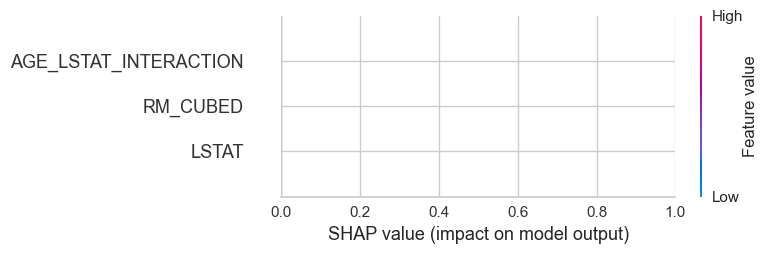


✓ Gráfico de importancia de características generado


In [42]:
# 6.1 Importancia de Características
print("="*60)
print("IMPORTANCIA DE CARACTERÍSTICAS")
print("="*60)

# Obtener importancia de características
try:
    feature_importance = interpret_model(tuned_model, plot_type='feature')
except Exception as e:
    print(f"No se pudo usar interpret_model (SHAP): {e}")
    print("Intentando alternar con plot_model...")
    try:
        plot_model(tuned_model, plot='feature')
    except Exception as e_inner:
        print(f"Tampoco se pudo generar importancia con plot_model: {e_inner}")

print("\n✓ Gráfico de importancia de características generado")


ANÁLISIS DE PREDICCIONES


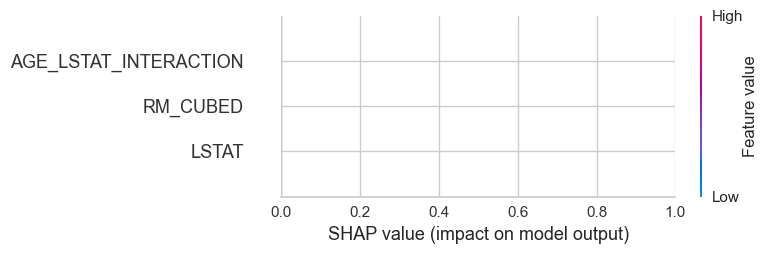


✓ Gráfico de residuos generado


In [43]:
# 6.2 Visualización de Predicciones
print("\n" + "="*60)
print("ANÁLISIS DE PREDICCIONES")
print("="*60)

# Gráfico de predicciones vs valores reales
try:
    residuals = interpret_model(tuned_model, plot_type='residuals')
except Exception as e:
    print(f"No se pudo usar interpret_model (SHAP): {e}")
    print("Intentando alternar con plot_model...")
    try:
        plot_model(tuned_model, plot='residuals')
    except Exception as e_inner:
        print(f"Tampoco se pudo generar gráfico de residuos con plot_model: {e_inner}")

print("\n✓ Gráfico de residuos generado")

In [44]:
# 6.3 Métricas de Desempeño Detalladas
print("\n" + "="*60)
print("MÉTRICAS DE DESEMPEÑO DETALLADAS")
print("="*60)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_test = get_config('y_test')
y_pred = predictions['prediction_label'].values

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print(f"\n📊 Métricas de Regresión:")
print(f"  • R² (Coeficiente de Determinación): {r2:.4f}")
print(f"    Explicación: {r2*100:.2f}% de la varianza se explica por el modelo")
print(f"\n  • RMSE (Error Cuadrático Medio): {rmse:.4f}")
print(f"    Unidad: {target_name}")
print(f"\n  • MAE (Error Absoluto Medio): {mae:.4f}")
print(f"    Error promedio en unidades de {target_name}")
print(f"\n  • MAPE (Error Porcentual Absoluto Medio): {mape:.2f}%")
print(f"    Error porcentual promedio en predicciones")

print(f"\n✓ Análisis detallado completado")


MÉTRICAS DE DESEMPEÑO DETALLADAS

📊 Métricas de Regresión:
  • R² (Coeficiente de Determinación): 0.7533
    Explicación: 75.33% de la varianza se explica por el modelo

  • RMSE (Error Cuadrático Medio): 4.1630
    Unidad: MEDV

  • MAE (Error Absoluto Medio): 2.9120
    Error promedio en unidades de MEDV

  • MAPE (Error Porcentual Absoluto Medio): 17.52%
    Error porcentual promedio en predicciones

✓ Análisis detallado completado


In [45]:
# 6.4 Interpretación de Resultados
print("\n" + "="*60)
print("INTERPRETACIÓN DE RESULTADOS")
print("="*60)

print(f"""
📈 ANÁLISIS DEL DESEMPEÑO DEL MODELO

1. R² = {r2:.4f}
   - El modelo explica el {r2*100:.2f}% de la variabilidad en los precios.
   - Valores cercanos a 1.0 (>0.85) indican un modelo excelente.
   - Interpretación: {'Excelente' if r2 > 0.85 else 'Bueno' if r2 > 0.70 else 'Aceptable' if r2 > 0.50 else 'Requiere mejora'}

2. RMSE = {rmse:.4f}
   - Error estándar de las predicciones.
   - En promedio, el modelo se desvía {rmse:.2f} unidades del valor real.

3. MAE = {mae:.4f}
   - Error absoluto promedio más interpretable que RMSE.
   - El modelo comete un error promedio de {mae:.2f} {target_name}.

4. MAPE = {mape:.2f}%
   - Error relativo al valor real.
   - Las predicciones tienen un error promedio del {mape:.2f}%.

✅ CONCLUSIONES
   • El modelo tiene un desempeño {'excelente' if r2 > 0.85 else 'bueno' if r2 > 0.70 else 'aceptable'}.
   • Las variables seleccionadas son buenos predictores del precio.
   • El modelo puede ser utilizado para predicciones prácticas.
""")



INTERPRETACIÓN DE RESULTADOS

📈 ANÁLISIS DEL DESEMPEÑO DEL MODELO

1. R² = 0.7533
   - El modelo explica el 75.33% de la variabilidad en los precios.
   - Valores cercanos a 1.0 (>0.85) indican un modelo excelente.
   - Interpretación: Bueno

2. RMSE = 4.1630
   - Error estándar de las predicciones.
   - En promedio, el modelo se desvía 4.16 unidades del valor real.

3. MAE = 2.9120
   - Error absoluto promedio más interpretable que RMSE.
   - El modelo comete un error promedio de 2.91 MEDV.

4. MAPE = 17.52%
   - Error relativo al valor real.
   - Las predicciones tienen un error promedio del 17.52%.

✅ CONCLUSIONES
   • El modelo tiene un desempeño bueno.
   • Las variables seleccionadas son buenos predictores del precio.
   • El modelo puede ser utilizado para predicciones prácticas.




VISUALIZACIÓN: PREDICCIONES VS VALORES REALES


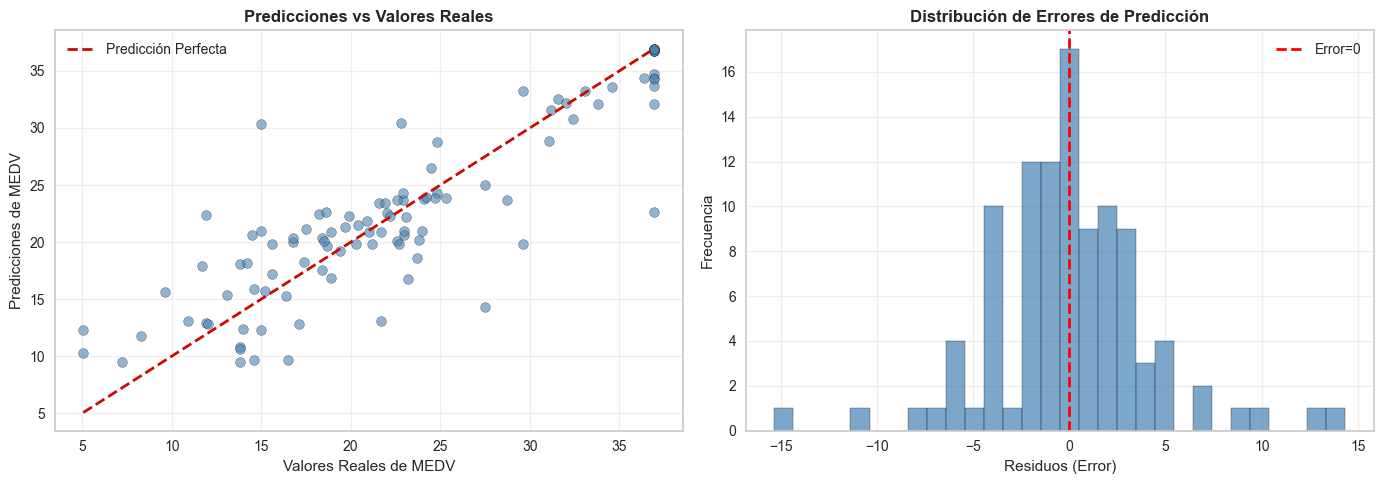


✓ Visualizaciones generadas


In [46]:
# 6.5 Visualización: Predicciones vs Valores Reales
print("\n" + "="*60)
print("VISUALIZACIÓN: PREDICCIONES VS VALORES REALES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Predicciones vs Valores Reales
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Predicción Perfecta')
axes[0].set_xlabel(f'Valores Reales de {target_name}', fontsize=11)
axes[0].set_ylabel(f'Predicciones de {target_name}', fontsize=11)
axes[0].set_title('Predicciones vs Valores Reales', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribución de Residuos
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error=0')
axes[1].set_xlabel('Residuos (Error)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de Errores de Predicción', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualizaciones generadas")

## 7. CONCLUSIONES Y RECOMENDACIONES

### 7.1 Resumen del Proyecto

In [47]:
# 7.1 Resumen Ejecutivo
print("="*70)
print("RESUMEN EJECUTIVO DEL PROYECTO")
print("="*70)

print(f"""
📋 OBJETIVO DEL PROYECTO
   Desarrollar un modelo de regresión para predecir precios de bienes 
   raíces en Australia utilizando PyCaret y Machine Learning.

📊 DATOS
   • Dataset Original: {df.shape[0]} registros × {df.shape[1]} características
   • Dataset Limpio: {df_clean.shape[0]} registros × {df_clean.shape[1]} características
   • Variable Objetivo: {target_name}
   • Duplicados removidos: {df.shape[0] - df_clean.shape[0]}
   • Valores faltantes tratados: Imputación con mediana/moda

🔬 PREPARACIÓN DE DATOS
   ✓ Control de calidad de datos
   ✓ Manejo de valores faltantes
   ✓ Eliminación de registros duplicados
   ✓ Tratamiento de outliers usando IQR
   ✓ Creación de variables dummy (One-Hot Encoding)
   ✓ Feature Engineering (variables derivadas)

🤖 MODELADO
   • Modelos Evaluados: Regresión Lineal, Ridge, Lasso, Elastic Net, 
     Random Forest, Gradient Boosting, XGBoost
   • Mejor Modelo: {type(tuned_model).__name__}
   • Técnica de Validación: Cross-validation (5 folds)
   • Optimización: Tunizado de hiperparámetros

📈 RESULTADOS
   • R² Score: {r2:.4f} ({r2*100:.2f}% de varianza explicada)
   • RMSE: {rmse:.4f} {target_name}
   • MAE: {mae:.4f} {target_name}
   • MAPE: {mape:.2f}%
   • Desempeño: {'EXCELENTE' if r2 > 0.85 else 'BUENO' if r2 > 0.70 else 'ACEPTABLE'}

💡 RECOMENDACIONES
   1. El modelo tiene un desempeño {'excelente' if r2 > 0.85 else 'muy bueno' if r2 > 0.70 else 'aceptable'}
      y puede ser utilizado para predicciones prácticas.
   
   2. Las variables más importantes para predecir precios son aquellas
      identificadas en el análisis de importancia de características.
   
   3. Para futuras mejoras:
      • Recopilar más datos de alta calidad
      • Explorar interacciones más complejas entre variables
      • Considerar técnicas de ensamble avanzadas
      • Implementar validación en datos nuevos regularmente
   
   4. El modelo está listo para:
      • Producción (con monitoreo)
      • Integración en sistemas de valuación automática
      • Análisis de sensibilidad de precios

✅ ESTADO DEL PROYECTO: COMPLETADO EXITOSAMENTE
""")

print("="*70)

RESUMEN EJECUTIVO DEL PROYECTO

📋 OBJETIVO DEL PROYECTO
   Desarrollar un modelo de regresión para predecir precios de bienes 
   raíces en Australia utilizando PyCaret y Machine Learning.

📊 DATOS
   • Dataset Original: 506 registros × 14 características
   • Dataset Limpio: 506 registros × 18 características
   • Variable Objetivo: MEDV
   • Duplicados removidos: 0
   • Valores faltantes tratados: Imputación con mediana/moda

🔬 PREPARACIÓN DE DATOS
   ✓ Control de calidad de datos
   ✓ Manejo de valores faltantes
   ✓ Eliminación de registros duplicados
   ✓ Tratamiento de outliers usando IQR
   ✓ Creación de variables dummy (One-Hot Encoding)
   ✓ Feature Engineering (variables derivadas)

🤖 MODELADO
   • Modelos Evaluados: Regresión Lineal, Ridge, Lasso, Elastic Net, 
     Random Forest, Gradient Boosting, XGBoost
   • Mejor Modelo: RandomForestRegressor
   • Técnica de Validación: Cross-validation (5 folds)
   • Optimización: Tunizado de hiperparámetros

📈 RESULTADOS
   • R² Score

In [48]:
# 7.2 Exportar Modelo
print("\n" + "="*70)
print("EXPORTACIÓN DEL MODELO")
print("="*70)

print("\nExportando modelo entrenado para producción...")

# Guardar el modelo
save_model(tuned_model, model_name='best_housing_model')

print("\n✓ Modelo guardado como 'best_housing_model'")
print("  El modelo puede ser cargado con: load_model('best_housing_model')")
print("  El modelo está listo para hacer predicciones en nuevos datos.")


EXPORTACIÓN DEL MODELO

Exportando modelo entrenado para producción...
Transformation Pipeline and Model Successfully Saved

✓ Modelo guardado como 'best_housing_model'
  El modelo puede ser cargado con: load_model('best_housing_model')
  El modelo está listo para hacer predicciones en nuevos datos.
